#### 1- Data preparation

In [319]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

def generate_data():
    num_classes = 10
    samples_per_class = 2000
    img_size = 14
    feature_dim = img_size * img_size
    variance = 50
    
    all_images = []
    all_labels = []
    
    means = np.random.uniform(low=-5, high=5, size=(num_classes, feature_dim))
    # print("means:" , means)
    
    for class_id in range(num_classes):
        class_mean = means[class_id]
        cov = np.eye(feature_dim) * variance
        class_samples = np.random.multivariate_normal(class_mean, cov, samples_per_class)
        class_samples = class_samples.reshape(samples_per_class, img_size, img_size)
        
        all_images.append(class_samples)
        all_labels.append(np.full(samples_per_class, class_id + 1))
    
    X = np.vstack(all_images)
    y = np.hstack(all_labels)
    
    return X, y

def split_data(X, y):
    X_flat = X.reshape(X.shape[0], -1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat, y, test_size=0.2, stratify=y, random_state = 1
    )
    return X_train, X_test, y_train, y_test

def to_torch_data(X_train, X_test, y_train, y_test):
    X_train_tensor = torch.FloatTensor(X_train).reshape(-1, 1, 14, 14)
    X_test_tensor = torch.FloatTensor(X_test).reshape(-1, 1, 14, 14)
    y_train_tensor = torch.LongTensor(y_train - 1)
    y_test_tensor = torch.LongTensor(y_test - 1)
    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [286]:
class ToyDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

def create_loaders(X_train, X_test, y_train, y_test, batch_size=64):
    train_dataset = ToyDataset(X_train, y_train)
    test_dataset = ToyDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, train_dataset, test_dataset

def get_data(batch_size=64):
    X, y = generate_data()
    X_train, X_test, y_train, y_test = split_data(X, y)
    X_train, X_test, y_train, y_test = to_torch_data(X_train, X_test, y_train, y_test)
    train_loader, test_loader, train_dataset, test_dataset = create_loaders(
        X_train, X_test, y_train, y_test, batch_size
    )
    return train_loader, test_loader, train_dataset, test_dataset

In [287]:
import matplotlib.pyplot as plt

def report_and_visualize(dataset, num_samples=10):
    images = dataset.images.numpy()
    labels = dataset.labels.numpy()
    
    print(f'num saples: {len(dataset)}')
    print(f'shape: {images.shape[1:]}')
    print(f'mean: {images.mean():.2f}')
    print(f'std: {images.std():.2f}')
    
    unique, counts = np.unique(labels, return_counts=True)
    print('\n class dists:')
    for c, cnt in zip(unique, counts):
        print(f'  class {c+1}: {cnt} sample ({cnt/len(dataset)*100:.1f}%)')
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i in range(10):
        row, col = i // 5, i % 5
        class_mask = labels == i
        if class_mask.any():
            sample_idx = np.where(class_mask)[0][0]
            axes[row, col].imshow(images[sample_idx, 0], cmap='gray')
        axes[row, col].set_title(f'class {i+1}')
        axes[row, col].axis('off')
    
    plt.suptitle('sample ')
    plt.tight_layout()
    plt.show()

means: [[ 0.95028183  2.70952983  0.40967118 ...  4.70437435 -2.29679521
   3.64849386]
 [ 0.8815974  -1.50538426 -0.04535271 ... -0.94008599  4.68728094
  -3.66551582]
 [-2.34230337  3.87575212 -3.05059523 ...  2.24690991 -3.37027305
  -3.00690743]
 ...
 [-0.81859594 -1.16217289  0.84404687 ... -4.14182288  4.56387918
  -4.64889428]
 [-3.86013083 -2.24965743 -0.2440805  ... -2.36700514  1.14282176
  -2.8518245 ]
 [ 1.39373779  1.21058729 -3.91469997 ... -0.55503785  0.19977097
   2.32743428]]
train
num saples: 16000
shape: (1, 14, 14)
mean: 0.03
std: 7.62

 class dists:
  class 1: 1600 sample (10.0%)
  class 2: 1600 sample (10.0%)
  class 3: 1600 sample (10.0%)
  class 4: 1600 sample (10.0%)
  class 5: 1600 sample (10.0%)
  class 6: 1600 sample (10.0%)
  class 7: 1600 sample (10.0%)
  class 8: 1600 sample (10.0%)
  class 9: 1600 sample (10.0%)
  class 10: 1600 sample (10.0%)


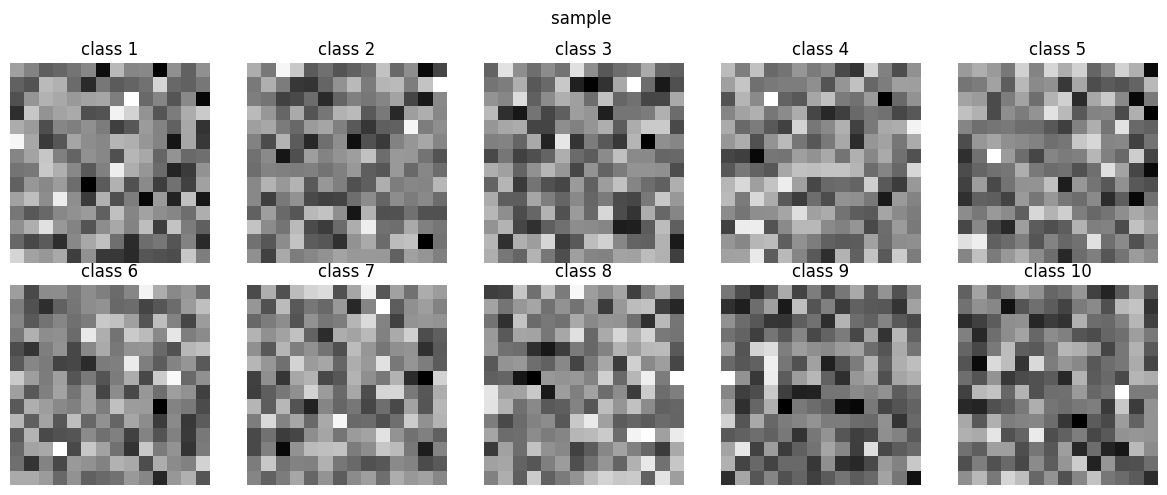

test
num saples: 4000
shape: (1, 14, 14)
mean: 0.05
std: 7.63

 class dists:
  class 1: 400 sample (10.0%)
  class 2: 400 sample (10.0%)
  class 3: 400 sample (10.0%)
  class 4: 400 sample (10.0%)
  class 5: 400 sample (10.0%)
  class 6: 400 sample (10.0%)
  class 7: 400 sample (10.0%)
  class 8: 400 sample (10.0%)
  class 9: 400 sample (10.0%)
  class 10: 400 sample (10.0%)


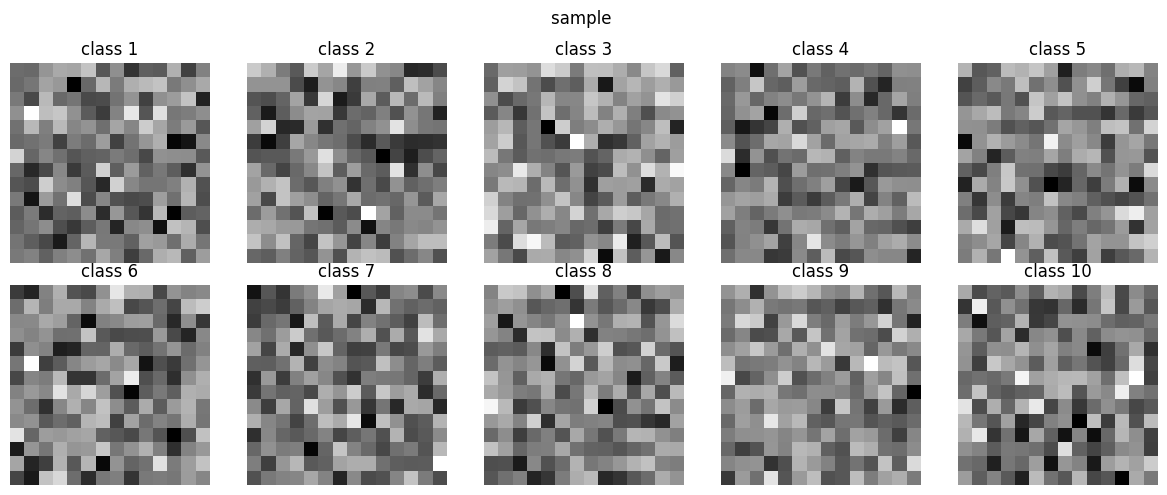

In [288]:
batch_size = 64
train_loader, test_loader, train_dataset, test_dataset = get_data(batch_size)

print('train')
report_and_visualize(train_dataset)

print('test')
report_and_visualize(test_dataset)

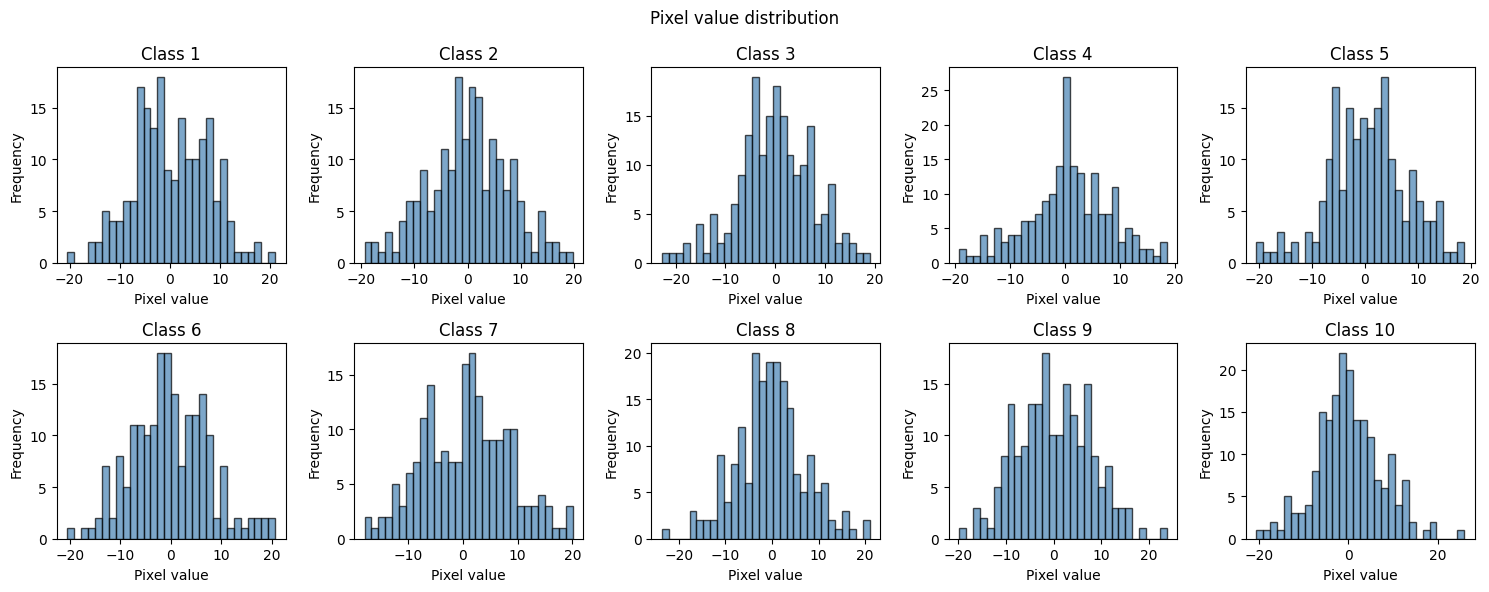

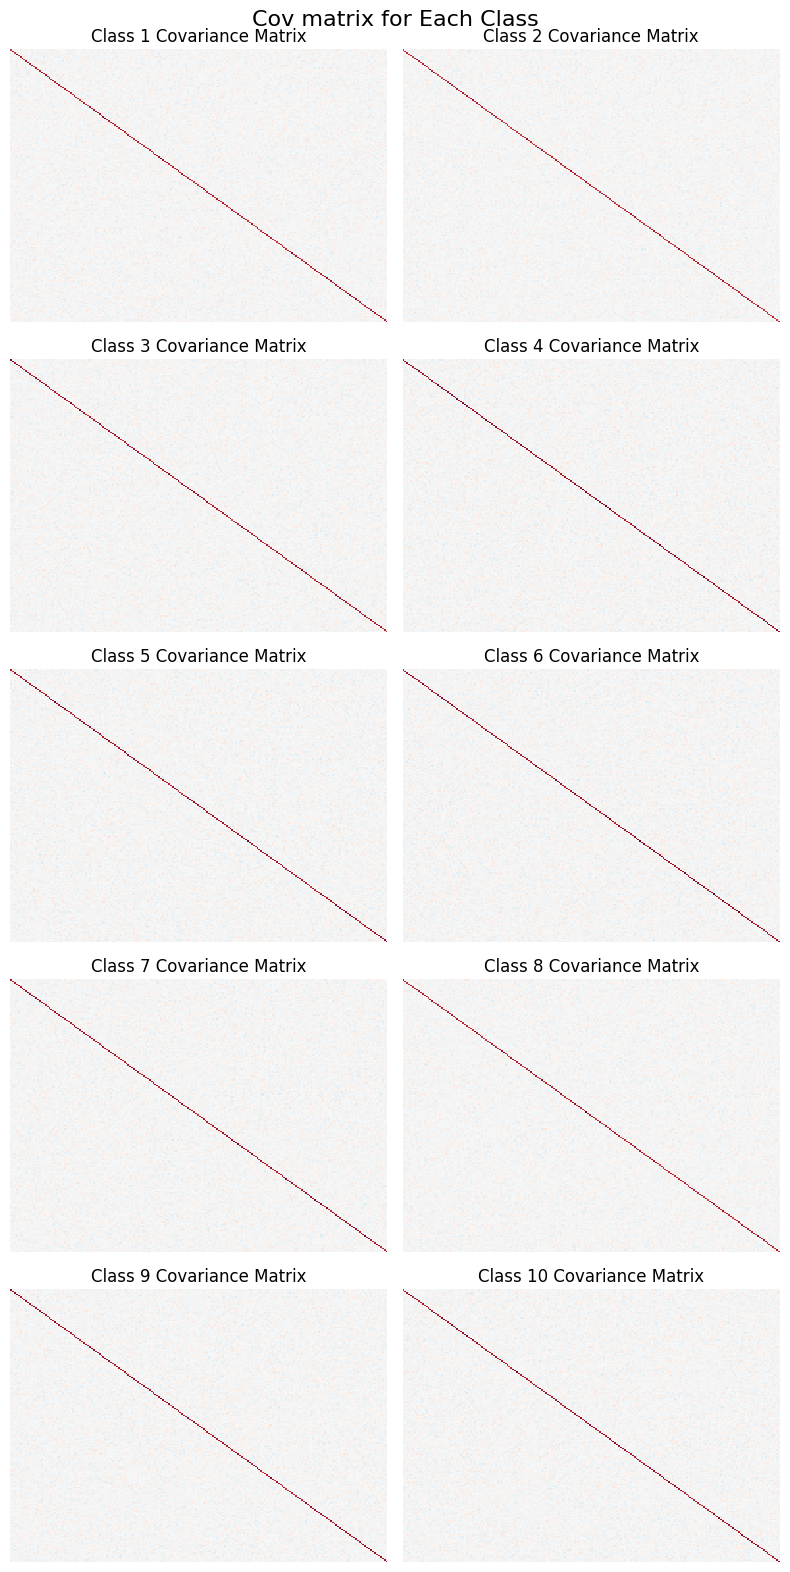

In [289]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_class_covariance(loader, dataset):
    images = dataset.images.numpy()
    labels = dataset.labels.numpy()
    
    class_means = {}
    class_covs = {}
    
    for class_id in range(10):
        class_samples = images[labels == class_id]
        class_flat = class_samples.reshape(class_samples.shape[0], -1)
        class_mean = class_flat.mean(axis=0)
        class_cov = np.cov(class_flat.T)
        
        class_means[class_id] = class_mean
        class_covs[class_id] = class_cov
    
    return class_means, class_covs

def visualize_class_histograms(dataset):
    images = dataset.images.numpy()
    labels = dataset.labels.numpy()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    for class_id in range(10):
        row, col = class_id // 5, class_id % 5
        class_samples = images[labels == class_id]
        sample_idx = np.random.randint(0, len(class_samples))
        sample = class_samples[sample_idx, 0].flatten()
        
        axes[row, col].hist(sample, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[row, col].set_title(f'Class {class_id+1}')
        axes[row, col].set_xlabel('Pixel value')
        axes[row, col].set_ylabel('Frequency')
    
    plt.suptitle('Pixel value distribution')
    plt.tight_layout()
    plt.show()


def visualize_covariance_matrices(class_covs, num_classes=10):
    fig, axes = plt.subplots(5, 2, figsize=(8, 16))
    for class_id in range(num_classes):
        row, col = class_id // 2, class_id % 2
        
        sns.heatmap(class_covs[class_id], 
                    ax=axes[row, col],
                    cmap='RdBu_r',
                    center=0,
                    cbar=False,
                    xticklabels=False,
                    yticklabels=False)
        
        axes[row, col].set_title(f'Class {class_id+1} Covariance Matrix')
    
    plt.suptitle('Cov matrix for Each Class', fontsize=16)
    plt.tight_layout()
    plt.show()

class_means, class_covs = compute_class_covariance(test_loader, test_dataset)
visualize_class_histograms(train_dataset)
visualize_covariance_matrices(class_covs)

#### 2- Base CNN model with softmax

In [290]:
from torch import nn
import torch.optim as optim

class MNISTNetwork(nn.Module):
    def __init__(self, num_classes=10):
        super(MNISTNetwork, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 1 * 1, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNISTNetwork(num_classes=10)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'network structure: {model}')


Total parameters: 322,026
network structure: MNISTNetwork(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): ReLU()
    (3): 

In [291]:
def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    weight_decay = lr * 0.01
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct_test / total_test
        test_losses.append(avg_test_loss)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    
    return train_losses, test_losses, train_accs, test_accs

In [292]:
batch_size = 64
train_loader, test_loader, train_dataset, test_dataset = get_data(batch_size)

model = MNISTNetwork(num_classes=10)

train_losses, test_losses, train_accs, test_accs = train_model(
    model, train_loader, test_loader, epochs=30, lr=0.001
)

means: [[ 4.99804138 -4.0547584   2.12568835 ... -3.39601832 -4.22439484
  -3.06044195]
 [ 2.10045544 -3.25640463  3.75132491 ... -0.49555124  4.89037207
  -3.32897177]
 [-2.01483528 -2.10107484  1.61794196 ... -3.66452001 -0.76164709
   2.82649773]
 ...
 [ 2.61926194  0.48611322 -4.20577846 ...  4.6869158  -0.61359542
  -3.44073903]
 [-3.53322413 -2.19235071  0.37449695 ...  0.75156889  2.52609545
   2.5375975 ]
 [-1.24388129  0.48577026  3.89980297 ...  0.90888809  1.80879433
  -3.17510305]]
Epoch  5/30 | Train Loss: 0.0799 | Train Acc: 97.51% | Test Loss: 0.1367 | Test Acc: 96.12%
Epoch 10/30 | Train Loss: 0.0614 | Train Acc: 98.13% | Test Loss: 0.1748 | Test Acc: 95.65%
Epoch 15/30 | Train Loss: 0.0395 | Train Acc: 98.93% | Test Loss: 0.1117 | Test Acc: 97.50%
Epoch 20/30 | Train Loss: 0.0513 | Train Acc: 98.72% | Test Loss: 0.1944 | Test Acc: 95.65%
Epoch 25/30 | Train Loss: 0.0359 | Train Acc: 99.09% | Test Loss: 0.1835 | Test Acc: 96.60%
Epoch 30/30 | Train Loss: 0.0347 | Train 

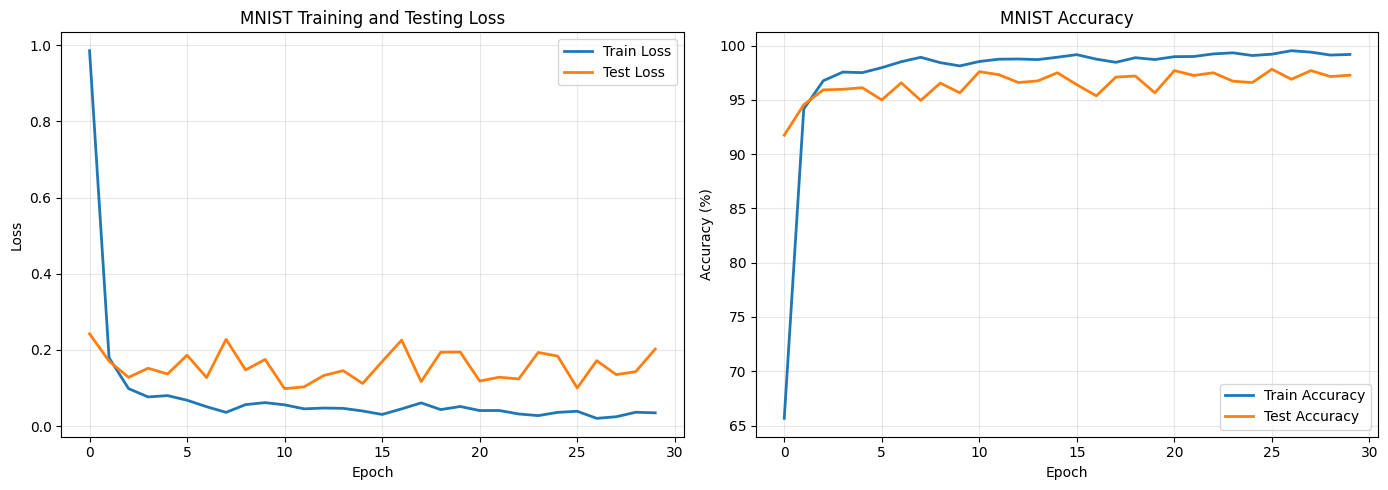

In [293]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(test_losses, label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST Training and Testing Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

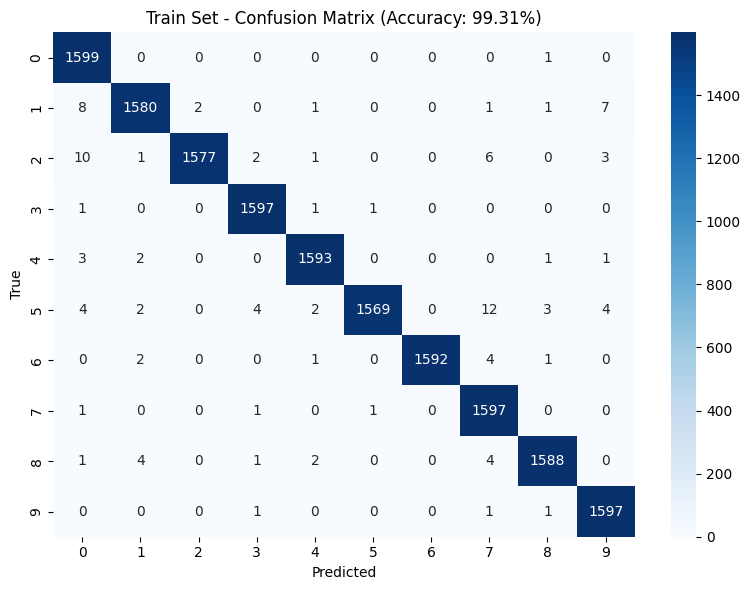

Train Accuracy: 99.31%


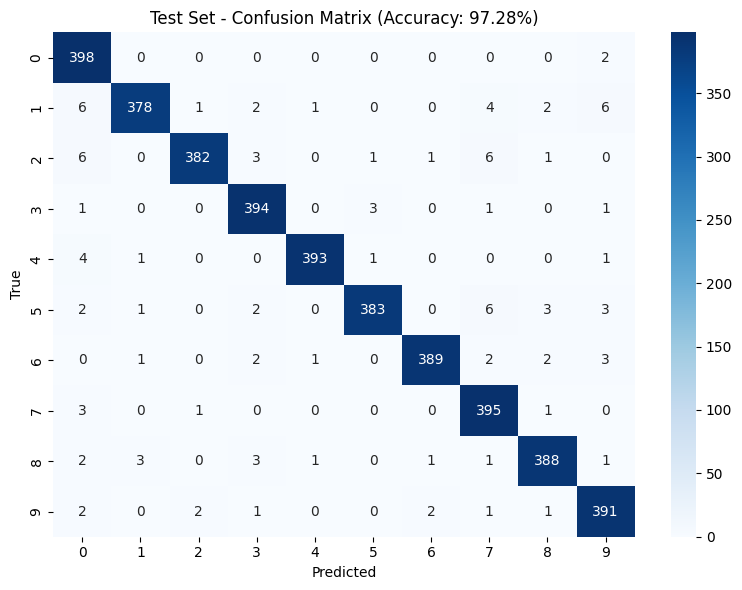

Test Accuracy: 97.28%


In [294]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

def evaluate_model(model, train_loader, test_loader):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    results = {}
    
    for name, loader in [('Train', train_loader), ('Test', test_loader)]:
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
        
        cm = confusion_matrix(all_labels, all_preds)
        acc = accuracy_score(all_labels, all_preds)
        results[name] = {'cm': cm, 'acc': acc}
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=range(10), yticklabels=range(10))
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'{name} Set - Confusion Matrix (Accuracy: {acc*100:.2f}%)')
        plt.tight_layout()
        plt.show()
        
        print(f'{name} Accuracy: {acc*100:.2f}%')
    
    return results

results = evaluate_model(model, train_loader, test_loader)

In [295]:
train_acc = results['Train']['acc'] * 100
test_acc = results['Test']['acc'] * 100
gap = train_acc - test_acc

print(f'Train Accuracy: {train_acc:.2f}%')
print(f'Test Accuracy: {test_acc:.2f}%')
print(f'Gap: {gap:.2f}%')

print()

cm = results['Test']['cm']
for i in range(10):
    misclassified_as = []
    for j in range(10):
        if i != j and cm[i, j] > 0:
            misclassified_as.append((j, cm[i, j]))
    if misclassified_as:
        misclassified_as.sort(key=lambda x: x[1], reverse=True)
        top_confusion = misclassified_as[:3]
        print(f'Class {i} often confused with: {[c[0] for c in top_confusion]}')

Train Accuracy: 99.31%
Test Accuracy: 97.28%
Gap: 2.03%

Class 0 often confused with: [9]
Class 1 often confused with: [0, 9, 7]
Class 2 often confused with: [0, 7, 3]
Class 3 often confused with: [5, 0, 7]
Class 4 often confused with: [0, 1, 5]
Class 5 often confused with: [7, 8, 9]
Class 6 often confused with: [9, 3, 7]
Class 7 often confused with: [0, 2, 8]
Class 8 often confused with: [1, 3, 0]
Class 9 often confused with: [0, 2, 6]


In [296]:
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.features = model.features
        self.classifier_part = nn.Sequential(
            model.classifier[0],
            model.classifier[1],
            model.classifier[2],
            model.classifier[3],
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier_part(x)
        return x

def extract_features(model, loader):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    feature_extractor = FeatureExtractor(model).to(device)
    feature_extractor.eval()
    
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = feature_extractor(images)
            all_features.extend(features.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_features), np.array(all_labels)

features, labels = extract_features(model, test_loader)
print(f'Features shape: {features.shape}')
print(f'Labels shape: {labels.shape}')

Features shape: (4000, 10)
Labels shape: (4000,)


In [297]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.2%}')

Variance explained by PC1: 29.79%
Variance explained by PC2: 27.38%
Total variance explained: 57.17%


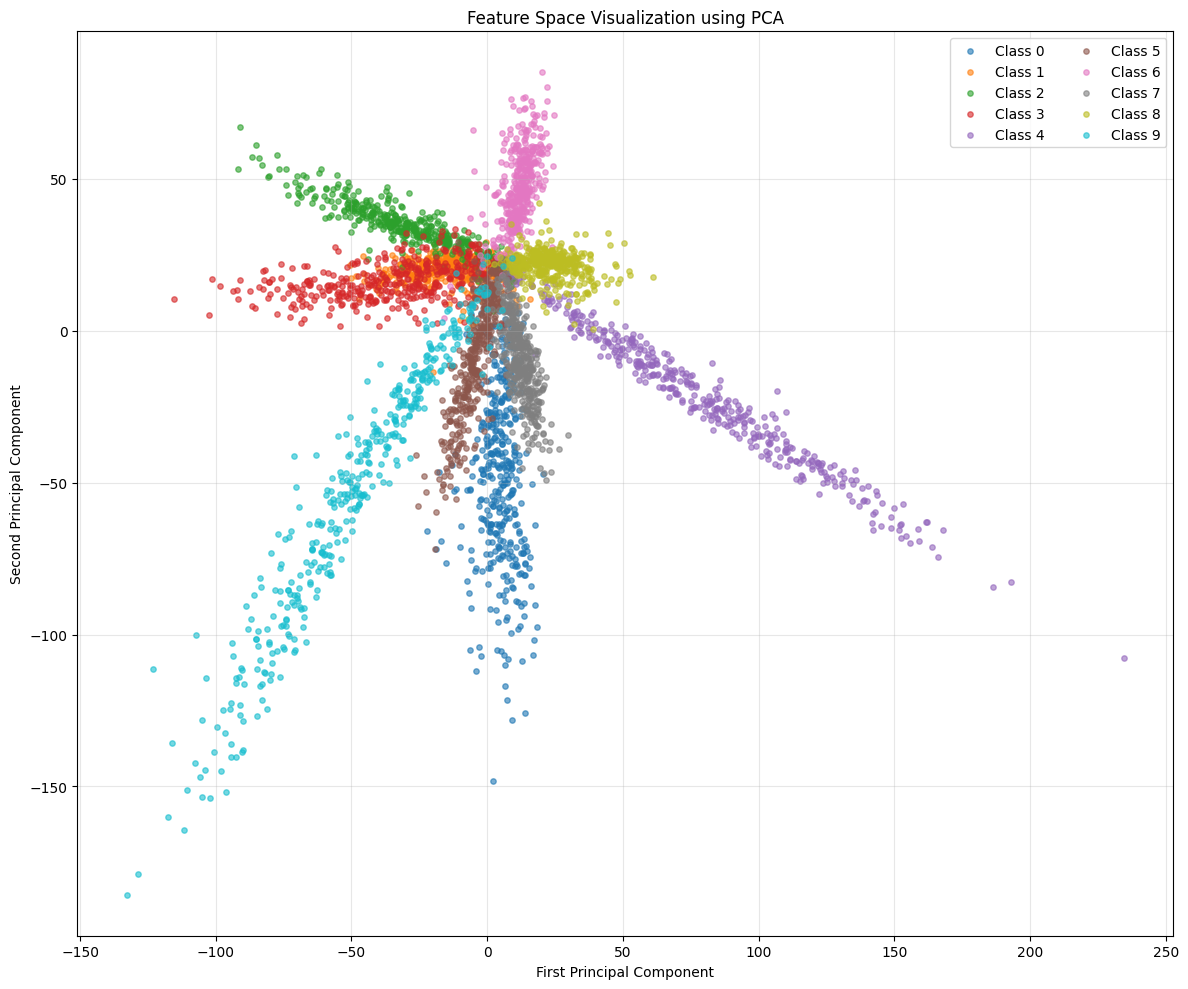

In [301]:
plt.figure(figsize=(12, 10))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for class_id in range(10):
    mask = labels == class_id
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                c=[colors[class_id]], label=f'Class {class_id}', 
                alpha=0.6, s=15)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Feature Space Visualization using PCA')
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [307]:
unique_classes = np.unique(labels)
class_centers = []
for class_id in unique_classes:
    mask = labels == class_id
    center = features_2d[mask].mean(axis=0)
    class_centers.append(center)
    
    intra_dist = np.mean(np.linalg.norm(features_2d[mask] - center, axis=1))
    print(f'Class {class_id}: center = ({center[0]:.2f}, {center[1]:.2f}), intra-class spread = {intra_dist:.2f}')

inter_distances = []
for i in range(len(class_centers)):
    for j in range(i+1, len(class_centers)):
        dist = np.linalg.norm(class_centers[i] - class_centers[j])
        inter_distances.append(dist)
        print(f'Distance between Class {i} and Class {j}: {dist:.2f}')

print(f'\nAverage inter-class distance: {np.mean(inter_distances):.2f}')
print(f'Average intra-class spread: {np.mean([np.linalg.norm(features_2d[labels==c] - features_2d[labels==c].mean(axis=0), axis=1).mean() for c in range(10)]):.2f}')


Class 0: center = (4.70, -47.30), intra-class spread = 25.08
Class 1: center = (-13.00, 19.81), intra-class spread = 11.97
Class 2: center = (-30.87, 34.77), intra-class spread = 17.58
Class 3: center = (-34.98, 16.54), intra-class spread = 20.65
Class 4: center = (79.87, -22.30), intra-class spread = 36.52
Class 5: center = (-4.21, -7.97), intra-class spread = 17.81
Class 6: center = (11.78, 47.24), intra-class spread = 11.27
Class 7: center = (12.35, -9.74), intra-class spread = 11.97
Class 8: center = (23.20, 21.68), intra-class spread = 8.81
Class 9: center = (-48.84, -52.73), intra-class spread = 43.36
Distance between Class 0 and Class 1: 69.41
Distance between Class 0 and Class 2: 89.45
Distance between Class 0 and Class 3: 75.17
Distance between Class 0 and Class 4: 79.21
Distance between Class 0 and Class 5: 40.33
Distance between Class 0 and Class 6: 94.80
Distance between Class 0 and Class 7: 38.33
Distance between Class 0 and Class 8: 71.41
Distance between Class 0 and Clas

#### 3- Angular margin loss implementation

In [312]:
class AngularMarginNetwork(nn.Module):
    def __init__(self, num_classes=10, embedding_size=128):
        super(AngularMarginNetwork, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 1 * 1, embedding_size),
            nn.BatchNorm1d(embedding_size),
        )
        
        self.fc = nn.Linear(embedding_size, num_classes, bias=False)
    
    def forward(self, x):
        x = self.features(x)
        embedding = self.embedding(x)
        
        embedding_norm = torch.nn.functional.normalize(embedding, p=2, dim=1)
        weight_norm = torch.nn.functional.normalize(self.fc.weight, p=2, dim=1)
        logits = torch.mm(embedding_norm, weight_norm.t())
        
        return logits, embedding_norm

model = AngularMarginNetwork(num_classes=10, embedding_size=128)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 304,480


In [313]:
class AngularMarginLoss(nn.Module):
    def __init__(self, margin=0.3, scale=30):
        super(AngularMarginLoss, self).__init__()
        self.margin = margin
        self.scale = scale
    
    def forward(self, logits, labels):
        batch_size = logits.size(0)
        
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, labels.unsqueeze(1), 1)
        
        cos_theta = logits
        cos_theta_m = cos_theta - self.margin * one_hot
        
        final_logits = self.scale * cos_theta_m
        loss = torch.nn.functional.cross_entropy(final_logits, labels)
        
        return loss

def train_angular_model(model, train_loader, test_loader, epochs=30, lr=0.001, margin=0.3, scale=30):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    weight_decay = lr * 0.01
    criterion = AngularMarginLoss(margin=margin, scale=scale)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits, _ = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                logits, _ = model(images)
                loss = criterion(logits, labels)
                
                test_loss += loss.item()
                _, predicted = torch.max(logits, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct_test / total_test
        test_losses.append(avg_test_loss)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    
    return train_losses, test_losses, train_accs, test_accs

In [315]:
batch_size = 64
train_loader, test_loader, train_dataset, test_dataset = get_data(batch_size)

model_angular = AngularMarginNetwork(num_classes=10, embedding_size=128)

train_losses, test_losses, train_accs, test_accs = train_angular_model(
    model_angular, train_loader, test_loader, epochs=30, lr=0.001, margin=0.3, scale=30
)

print(f'\nFinal Test Accuracy: {test_accs[-1]:.2f}%')

means: [[-2.04779952  3.6914073   3.68531784 ... -1.56560779  4.18905094
   3.13508284]
 [ 1.81776514  4.25511763  3.76485009 ...  2.6864161   2.92778593
  -3.48882815]
 [-3.32757855 -1.17320121 -4.87700377 ...  4.82106573  1.42648451
  -4.75995329]
 ...
 [ 4.94210506 -4.35067544  0.24557634 ... -4.99507395 -1.39017941
   1.50482195]
 [ 3.1180888   3.69456057 -2.45448874 ... -4.2881331  -4.06468795
   3.57724958]
 [-0.89113736 -2.47798047  0.11679025 ...  1.03525279 -4.05099272
  -1.03886128]]
Epoch  5/30 | Train Loss: 0.1880 | Train Acc: 99.49% | Test Loss: 0.6757 | Test Acc: 97.03%
Epoch 10/30 | Train Loss: 0.0892 | Train Acc: 99.75% | Test Loss: 0.3993 | Test Acc: 98.28%
Epoch 15/30 | Train Loss: 0.0793 | Train Acc: 99.70% | Test Loss: 0.4221 | Test Acc: 98.38%
Epoch 20/30 | Train Loss: 0.0633 | Train Acc: 99.81% | Test Loss: 0.2862 | Test Acc: 98.80%
Epoch 25/30 | Train Loss: 0.0664 | Train Acc: 99.80% | Test Loss: 0.2974 | Test Acc: 98.88%
Epoch 30/30 | Train Loss: 0.0400 | Train 

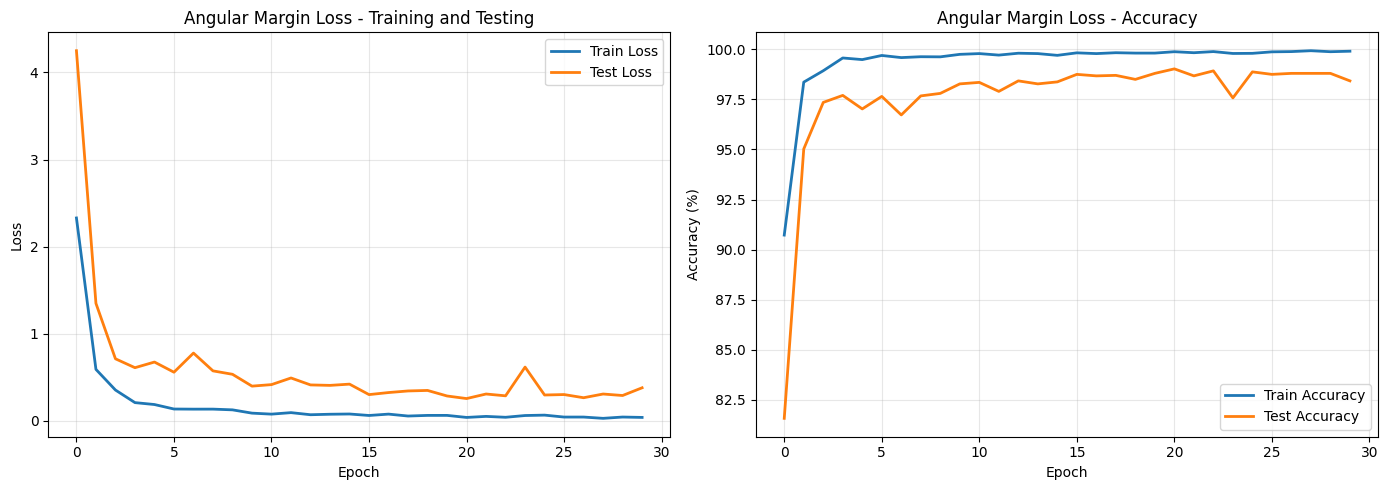

In [316]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(test_losses, label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Angular Margin Loss - Training and Testing')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Angular Margin Loss - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [320]:
batch_sizes = [32, 64, 128]
margin_results = {}

for bs in batch_sizes:
    print(f'\nTraining with batch_size = {bs}')
    train_loader, test_loader, _, _ = get_data(bs)
    
    model_temp = AngularMarginNetwork(num_classes=10, embedding_size=128)
    _, _, _, test_accs_temp = train_angular_model(
        model_temp, train_loader, test_loader, epochs=15, lr=0.001, margin=0.3, scale=30
    )
    
    margin_results[bs] = test_accs_temp[-1]
    print(f'Batch size {bs} -> Final test accuracy: {test_accs_temp[-1]:.2f}%')

print('\nEffect of Batch Size on Angular Margin Loss')
for bs, acc in margin_results.items():
    print(f'Batch size {bs}: {acc:.2f}%')


Training with batch_size = 32
Epoch  5/15 | Train Loss: 0.2771 | Train Acc: 99.00% | Test Loss: 0.7783 | Test Acc: 96.95%
Epoch 10/15 | Train Loss: 0.1392 | Train Acc: 99.55% | Test Loss: 0.4484 | Test Acc: 98.25%
Epoch 15/15 | Train Loss: 0.0910 | Train Acc: 99.71% | Test Loss: 0.3473 | Test Acc: 98.58%
Batch size 32 -> Final test accuracy: 98.58%

Training with batch_size = 64
Epoch  5/15 | Train Loss: 0.1872 | Train Acc: 99.46% | Test Loss: 1.1958 | Test Acc: 95.05%
Epoch 10/15 | Train Loss: 0.0871 | Train Acc: 99.76% | Test Loss: 0.4709 | Test Acc: 98.15%
Epoch 15/15 | Train Loss: 0.0651 | Train Acc: 99.83% | Test Loss: 0.3256 | Test Acc: 98.75%
Batch size 64 -> Final test accuracy: 98.75%

Training with batch_size = 128
Epoch  5/15 | Train Loss: 0.1103 | Train Acc: 99.86% | Test Loss: 0.4906 | Test Acc: 98.45%
Epoch 10/15 | Train Loss: 0.0794 | Train Acc: 99.88% | Test Loss: 0.5531 | Test Acc: 97.88%
Epoch 15/15 | Train Loss: 0.0561 | Train Acc: 99.90% | Test Loss: 0.5837 | Test 

In [340]:
def extract_embeddings(model, loader):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, embeddings = model(images)
            all_embeddings.extend(embeddings.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_embeddings), np.array(all_labels)

embeddings, emb_labels = extract_embeddings(model_angular, test_loader)
print(f'Embeddings shape: {embeddings.shape}')

Embeddings shape: (4000, 128)


Variance explained by PC1: 16.84%
Variance explained by PC2: 14.45%


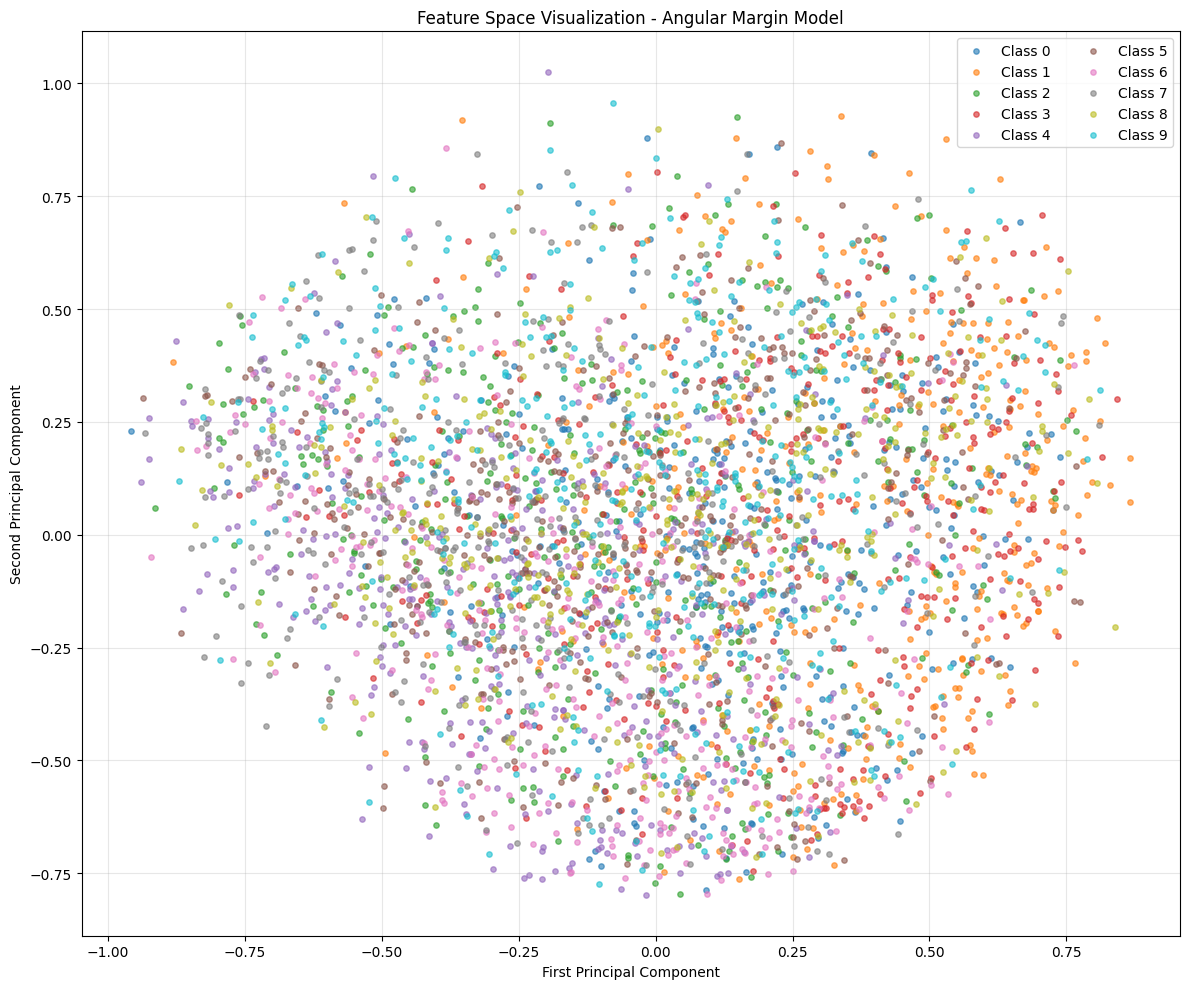

In [342]:
from sklearn.decomposition import PCA

pca_angular = PCA(n_components=2)
embeddings_2d = pca_angular.fit_transform(embeddings)

print(f'Variance explained by PC1: {pca_angular.explained_variance_ratio_[0]:.2%}')
print(f'Variance explained by PC2: {pca_angular.explained_variance_ratio_[1]:.2%}')

plt.figure(figsize=(12, 10))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for class_id in range(10):
    mask = emb_labels == class_id
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                c=[colors[class_id]], label=f'Class {class_id}', 
                alpha=0.6, s=15)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Feature Space Visualization - Angular Margin Model')
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [343]:
print('Angular Margin Model Analysis')

class_centers_angular = []
for class_id in range(10):
    mask = emb_labels == class_id
    center = embeddings_2d[mask].mean(axis=0)
    class_centers_angular.append(center)
    intra_dist = np.mean(np.linalg.norm(embeddings_2d[mask] - center, axis=1))
    print(f'Class {class_id}: intra-class spread = {intra_dist:.2f}')

inter_distances_angular = []
for i in range(len(class_centers_angular)):
    for j in range(i+1, len(class_centers_angular)):
        dist = np.linalg.norm(class_centers_angular[i] - class_centers_angular[j])
        inter_distances_angular.append(dist)
        print(f'Distance between Class {i} and Class {j}: {dist:.2f}')

print(f'\nAverage inter-class distance: {np.mean(inter_distances_angular):.2f}')
print(f'Average intra-class spread: {np.mean([np.linalg.norm(embeddings_2d[emb_labels==c] - embeddings_2d[emb_labels==c].mean(axis=0), axis=1).mean() for c in range(10)]):.2f}')

Angular Margin Model Analysis
Class 0: intra-class spread = 0.41
Class 1: intra-class spread = 0.46
Class 2: intra-class spread = 0.47
Class 3: intra-class spread = 0.46
Class 4: intra-class spread = 0.42
Class 5: intra-class spread = 0.43
Class 6: intra-class spread = 0.45
Class 7: intra-class spread = 0.46
Class 8: intra-class spread = 0.43
Class 9: intra-class spread = 0.45
Distance between Class 0 and Class 1: 0.21
Distance between Class 0 and Class 2: 0.18
Distance between Class 0 and Class 3: 0.08
Distance between Class 0 and Class 4: 0.37
Distance between Class 0 and Class 5: 0.17
Distance between Class 0 and Class 6: 0.30
Distance between Class 0 and Class 7: 0.30
Distance between Class 0 and Class 8: 0.11
Distance between Class 0 and Class 9: 0.18
Distance between Class 1 and Class 2: 0.38
Distance between Class 1 and Class 3: 0.13
Distance between Class 1 and Class 4: 0.58
Distance between Class 1 and Class 5: 0.37
Distance between Class 1 and Class 6: 0.50
Distance between C